# ViT-Up Inference Example

Minimal ViT-Up inference: load a pretrained wrapper, run dense queries on one image, and visualize the resulting features with PCA.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

from vit_up.inference.vit_up_wrapper import ViTUpWrapper
from vit_up.utils import pca_utils

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_grad_enabled(False)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.9.0+cu128
Device: cuda


In [2]:
model_name = "vit_up_dinov3_splus"  # or "vit_up_dinov3_base"
query_res = 448
query_chunk_size = 4096

model = ViTUpWrapper(
    model_name,
    device=device,
    use_bfloat16=(device == "cuda"),
    query_chunk_size=query_chunk_size,
).eval()

Loading backbone: facebook/dinov3-vits16plus-pretrain-lvd1689m


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Loading weights from HF Hub: Krispin/vit-up/vit_up_dinov3_splus.safetensors
✓ Loaded 355 weight parameters


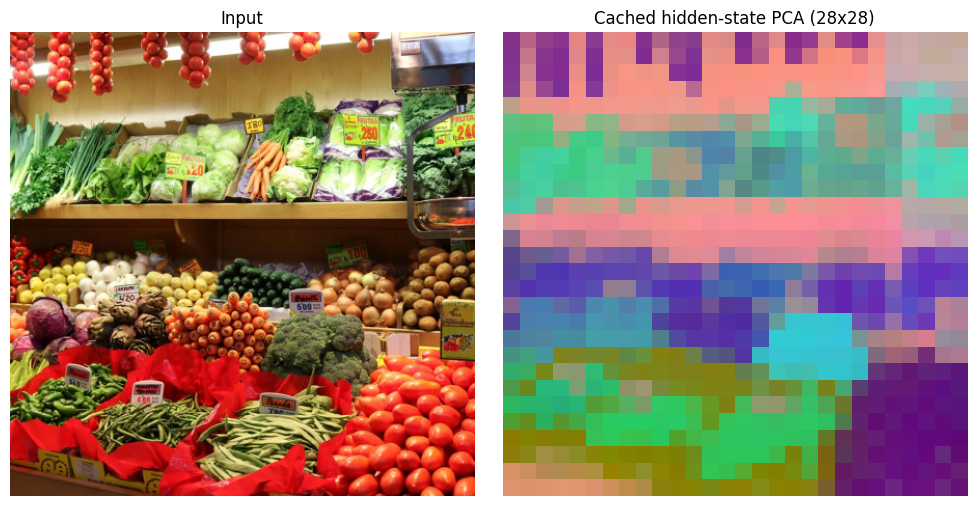

In [3]:
image_path = repo_root / "assets" / "fruit_store.png"
image = Image.open(image_path).convert("RGB")
image = T.CenterCrop(min(image.size))(image)

model.set_images(image)
cache_data = model.get_cache_data()
last_hidden_states = cache_data["layer_hidden_states_hwc"][-1][0].detach().float().cpu()
low_h, low_w, feat_dim = last_hidden_states.shape

low_features = last_hidden_states.reshape(low_h * low_w, feat_dim)
low_pca_scores, pca_mean, pca_std, _, pca_eigenvectors = pca_utils.pca(
    low_features,
    k=3,
    std_normalize=True,
)
low_pca_rgb, rgb_min, rgb_max = pca_utils.tensor_to_rgb(low_pca_scores)
low_pca_rgb = low_pca_rgb.reshape(low_h, low_w, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(low_pca_rgb.numpy())
axes[1].set_title(f"Cached hidden-state PCA ({low_h}x{low_w})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
coords = (torch.arange(query_res, device=device, dtype=torch.float32) + 0.5) / query_res
grid_y, grid_x = torch.meshgrid(coords, coords, indexing="ij")
query_coords = torch.stack((grid_x, grid_y), dim=-1).reshape(1, query_res * query_res, 2)

features = model(query_coords=query_coords)
features = features[0].detach().float().cpu()

print(f"Features: {tuple(features.shape)}")

/home/user/Documents/projects/vit-up/.venv/lib/python3.11/site-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()


Features: (200704, 384)


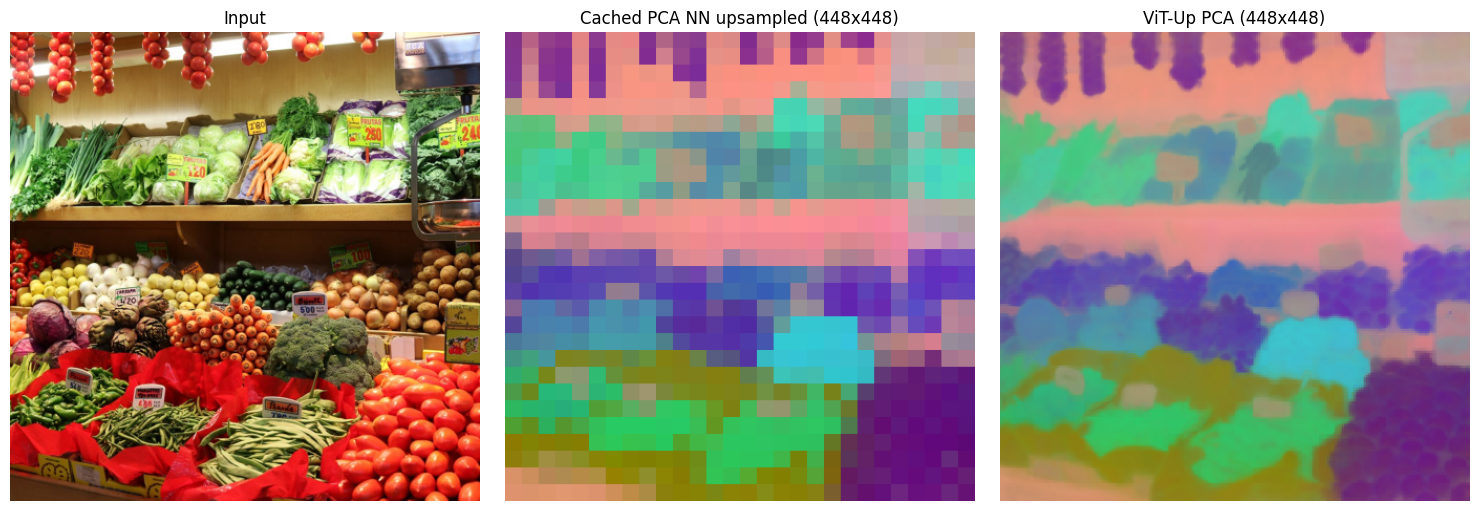

In [5]:
high_pca_scores = pca_utils.apply_pca(features, pca_eigenvectors, pca_mean, pca_std)
high_pca_rgb, _, _ = pca_utils.tensor_to_rgb(
    high_pca_scores,
    tensor_min=rgb_min,
    tensor_max=rgb_max,
)
high_pca_rgb = high_pca_rgb.reshape(query_res, query_res, 3)

low_pca_rgb_upsampled = F.interpolate(
    low_pca_rgb.permute(2, 0, 1).unsqueeze(0).float(),
    size=(query_res, query_res),
    mode="nearest",
)[0].permute(1, 2, 0).byte()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(low_pca_rgb_upsampled.numpy())
axes[1].set_title(f"Cached PCA NN upsampled ({query_res}x{query_res})")
axes[1].axis("off")

axes[2].imshow(high_pca_rgb.numpy())
axes[2].set_title(f"ViT-Up PCA ({query_res}x{query_res})")
axes[2].axis("off")

plt.tight_layout()
plt.show()